# Exploratory Data Analysis
Group 3  
Member: Yam Ching Long Angus

### Project Title
Video Game Sales (1980 - 2024) Analysis
### Project Objectives
To analyze video game sales from 1980 to 2024, identify key factors influencing sales performance (including platform, genre and region), and provide data-driven sales strategy recommendations for game publishers and developers.

### Dataset
A comprehensive collection of 64,000+ video games across more than 40 years of gaming history. The dataset provides a thorough look at how different genres, platforms, and publishers have performed globally and regionally.  

The dataset contains 14 features: 

- img: URL for game cover  

- title: Game title  

- console: Platform that the game was released on  

- genre: Genre of the game  

- publisher: Publisher of the game  

- developer: Developer of the game  

- critic_score: Metacritic score (out of 10)  

- total_sales: Global sales of copies in millions  

- na_sales: North American sales of copies in millions  

- jp_sales: Japanese sales of copies in millions  

- pal_sales: European & African sales of copies in millions  

- other_sales: Other regional sales of copies in millions  

- release_date: Date that the game was released on  

- last_update: Date that the data was last updated

### Data Preprocessing

To start with, we first download the scikit-learn library:

In [1]:
%pip install -U scikit-learn

Note: you may need to restart the kernel to use updated packages.


Then we import the necessary libraries and read the csv file:

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv("Video Games Sales (1980-2024) - Raw.csv")
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,17-09-2013,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,18-11-2014,03-01-2018
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,28-10-2002,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,17-09-2013,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,06-11-2015,14-01-2018


The csv file is successfully read. We now check the dimension of the dataset and the datatype of each column:

In [4]:
print(df.shape)
df.dtypes

(64016, 14)


img              object
title            object
console          object
genre            object
publisher        object
developer        object
critic_score    float64
total_sales     float64
na_sales        float64
jp_sales        float64
pal_sales       float64
other_sales     float64
release_date     object
last_update      object
dtype: object

The dataset has 14 columns and 64016 rows(excluding the header).  
As the columns 'img' and 'last_update' are irrelevant to our analysis, we drop these two columns:

In [5]:
df = df.drop(['img', 'last_update'], axis=1)
df.head()

,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,17-09-2013
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,18-11-2014
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,28-10-2002
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,17-09-2013
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,06-11-2015


We now check how many missing values there are in each column:

In [6]:
print("Missing values:")
print(df.isna().sum())

Missing values:
title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
dtype: int64


In the column 'developer', we fill the missing values with 'Unknown':

In [7]:
df['developer'] = df['developer'].fillna('Unknown')

In the column 'critic_score', we fill the missing values with the method of KNN Imputation. We choose K=5:

In [8]:
from sklearn.impute import KNNImputer
# Select columns
columns_to_use = ['critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']
df_subset = df[columns_to_use].copy()

# Apply KNN imputer
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(
    imputer.fit_transform(df_subset),
    columns=df_subset.columns
)

# Update critic_score
df['critic_score'] = df_imputed['critic_score']

We check the missing values in 'critic_score' after KNN Imputation:

In [9]:
print(df['critic_score'].isna().sum())

0


In the column 'total_sales', we delete the rows with the value 0 and with missing values:


In [10]:
df = df.dropna(subset=['total_sales'])
df = df[df['total_sales'] != 0]


In the columns 'na_sales','jp_sales','pal_sales' and 'other_sales', we fill the missing values with 0:


In [11]:
sales_columns = ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']
df[sales_columns] = df[sales_columns].fillna(0)

In the column 'other_sales', there are some date values. We only keep those rows where 'other_sales' is a float or integer:

In [12]:
df['other_sales'] = pd.to_numeric(df['other_sales'], errors='coerce')
df = df[df['other_sales'].notna()]

Finally, in the column 'release_date', we drop those rows with missing values, then we extract only the year from the date:

In [13]:
df = df.dropna(subset=['release_date'])

# Create a new column called 'release_year'
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce', dayfirst=True).dt.year

# Drop the original 'release_date' column
df.drop(columns=['release_date'], inplace=True)

Data preprocessing is now completed. We check the dimension of the cleaned dataset, then we extract the dataframe to a csv file:

In [14]:
print(df.shape)
df.to_csv("cleaned_dataset.csv", index=False)

(17508, 12)


### Data Analysis

Before performing the analysis, we first take a look at the top 10 bestselling games of all time:

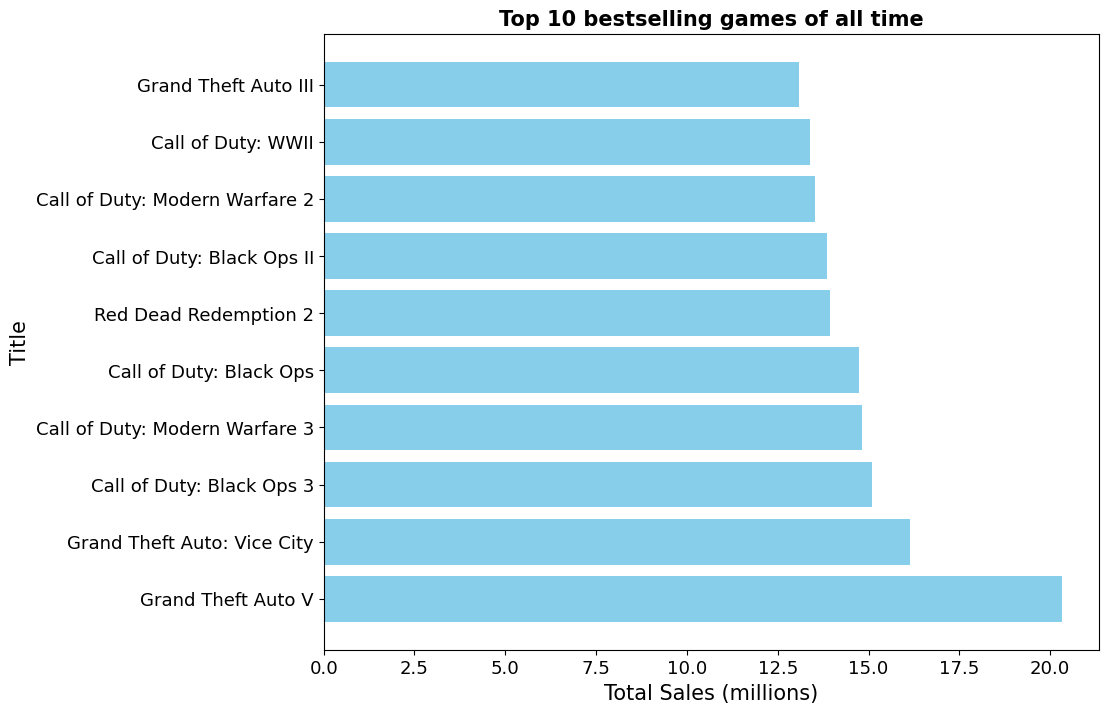

In [15]:
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the bar chart
ax.barh(df['title'][:15],df['total_sales'][:15],color = 'skyblue')

# Add labels and title
ax.set_xlabel('Total Sales (millions)',fontsize=15)
ax.set_ylabel('Title',fontsize=15)
ax.set_title('Top 10 bestselling games of all time',fontsize=15, fontweight='bold')
ax.tick_params(axis='both', labelsize=13)

# Show the plot
plt.show()

Now we can perform different analysis on the dataset.

##### Univariate Analysis

We first plot the distribution of total sales using a histogram and a box plot:  
(For both plots, we use a log scale for total sales for easy visualization)

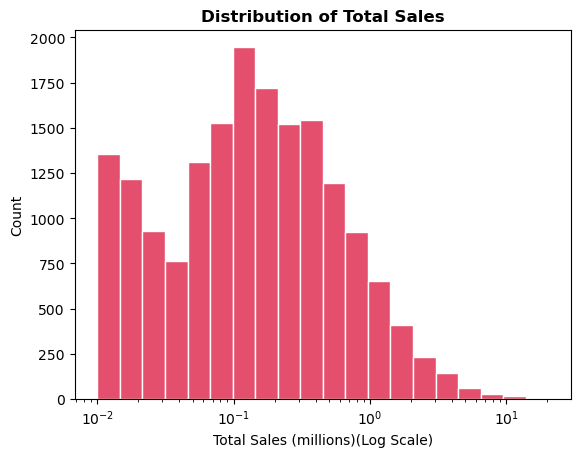

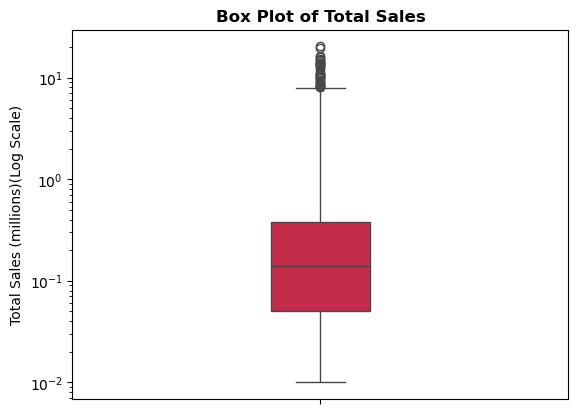

In [16]:
#histogram
sns.histplot(
 df['total_sales'], 
 bins=20,          
 stat='count',                
 color='crimson',
 edgecolor = 'white',
 log_scale=True)   
plt.title('Distribution of Total Sales',fontweight='bold')
plt.xlabel('Total Sales (millions)(Log Scale)')
plt.show()

#box plot
sns.boxplot(
    df['total_sales'],
    log_scale=True,
    color='crimson',
    width=0.2)
plt.title('Box Plot of Total Sales',fontweight='bold')
plt.ylabel('Total Sales (millions)(Log Scale)')
plt.show()


Observations:
- Histogram: The distribution is slightly right-skewed, indicating that the top sales are dominated by very few games.

- Box plot: There are many outliers, which again confirms that only a few games generate the majority of total sales.

Insights:
- Success is highly concentrated among those AAA IPs such as Grand Theft Auto, Call of Duty, FIFA.

- Game publishers like Rockstar Games, Activision and EA should continue to develop these famous IPs as they can bring huge profits, although not all of them can achieve high scores. Conversely, developing new IP is risky since a lot of money may be invested but results in low profits.

We then plot the distribution of critic score using a KDE plot and a boxplot:

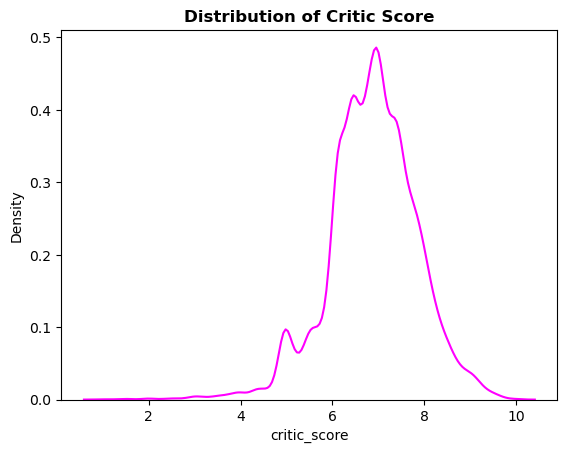

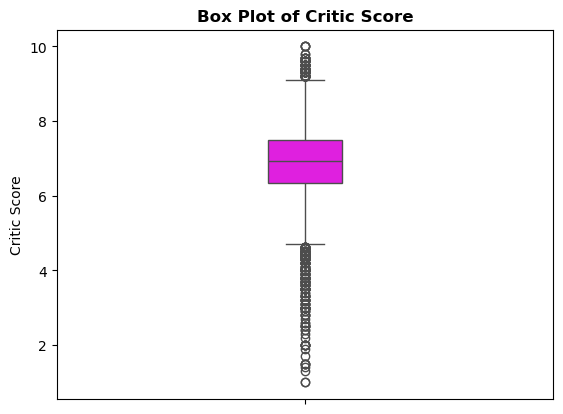

In [17]:
#KDE plot
sns.kdeplot(df['critic_score'],color='magenta') 
plt.title('Distribution of Critic Score',fontweight='bold') 
plt.show()

#box plot
sns.boxplot(
    df['critic_score'],
    color='magenta',
    width=0.15)
plt.title('Box Plot of Critic Score',fontweight='bold')
plt.ylabel('Critic Score')
plt.show()

Observations:
- Histogram: The distribution is slightly left-skewed, with median at around 7 and mode at around 6.7.

- Box plot: There are a lot of outliers both below the lower limit and above the upper limit.

Insights:
- The histogram shows that most games are concentrated at moderate scores, and the box plot reveals that there is a considerable amount of games which have very low scores (below 5), and quite a lot of games can reach high scores (above 9).

- The median 7 can be considered as industry standard. When making video games, game publishers and developers should target 7+ score to avoid negative perception.

##### Bivariate analysis

##### Total sales vs critic score
We want to find out the relationship between total sales and critic score. Must higher score indicate better sales? We use a scatter plot to demonstrate their relationship:

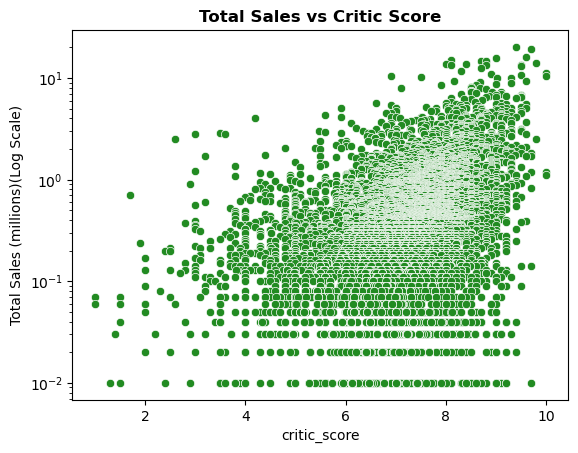

In [18]:
sns.scatterplot(data=df, x="critic_score", y="total_sales",color='forestgreen')
plt.yscale('log')
plt.ylabel('Total Sales (millions)(Log Scale)')
plt.title('Total Sales vs Critic Score',fontweight='bold')
plt.show()

We also calculate the correlation coefficient between total sales and critic score, which is:

In [19]:
correlation = df['critic_score'].corr(df['total_sales'])
print('Correlation = ',correlation)

Correlation =  0.33695185965566454


Observations:
- The correlation coefficient is around 0.34. From the scatter plot, we can see that there is a positive trend between sales and scores, but the relationship is not strong.

- High variance: for any given critic score, especially between 5 and 9, the sales can vary wildly.

Insights:
- High score does not necessarily mean high sales. As can be seen from the scatter plot, games with high scores (>9) can sell very poorly.

- It is extremely rare for a 'bad' game (score<3) to become a massive hit. If publishers want a game to sell millions of copies, it must acquire a relatively high score.

- Some indie games may have good reviews but low sales due to limited budget for promotion and advertisement.

##### Gamers' preference by genre
We then investigate the most popular genres over the years. Below is a horizontal bar chart showing which genres have the top sales:

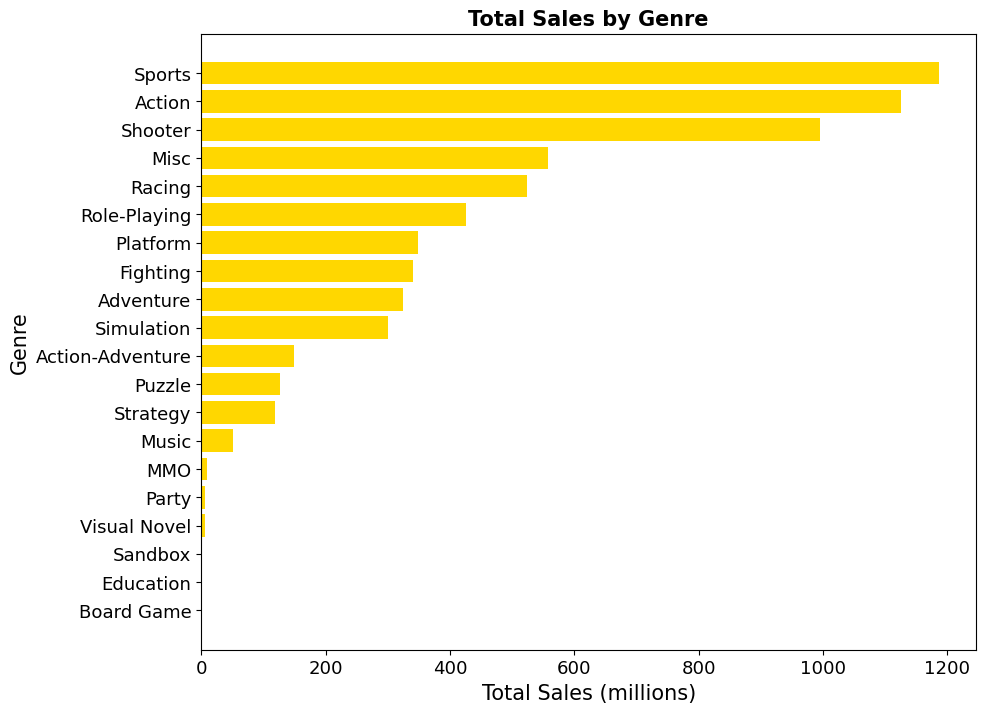

In [20]:
fig, ax = plt.subplots(figsize=(10, 8))

# Calculate the sum of total sales for each genre
sales_stats = df.groupby('genre')['total_sales'].sum().sort_values(ascending=True).reset_index()

# Plot the bar chart
ax.barh(sales_stats['genre'],sales_stats['total_sales'],color = 'gold')

# Add labels and title
ax.set_xlabel('Total Sales (millions)',fontsize=15)
ax.set_ylabel('Genre',fontsize=15)
ax.set_title('Total Sales by Genre',fontsize=15, fontweight='bold')
ax.tick_params(axis='both', labelsize=13)

# Show the plot
plt.show()

Observations:
- Over the past 40+ years of gaming history, the most popular genre is Sports games. The second is Action games while the third is Shooter games.

- Low-budget games like Simulation, Puzzle and Visual Novel games have relatively lower sales.

Insights:
- Game developers should prioritize the development of Sports, Action and Shooter games due to their large market.

- While a high score is important, it cannot overcome a small market. Therefore, the choice of Genre should be the first consideration. A perfect 10/10 Visual Novel game will probably sell less than a mediocre 6/10 Action game due to the genre's much smaller market size.

##### Market share by consoles
We then look at the market share by different consoles over the past years, using a pie chart:

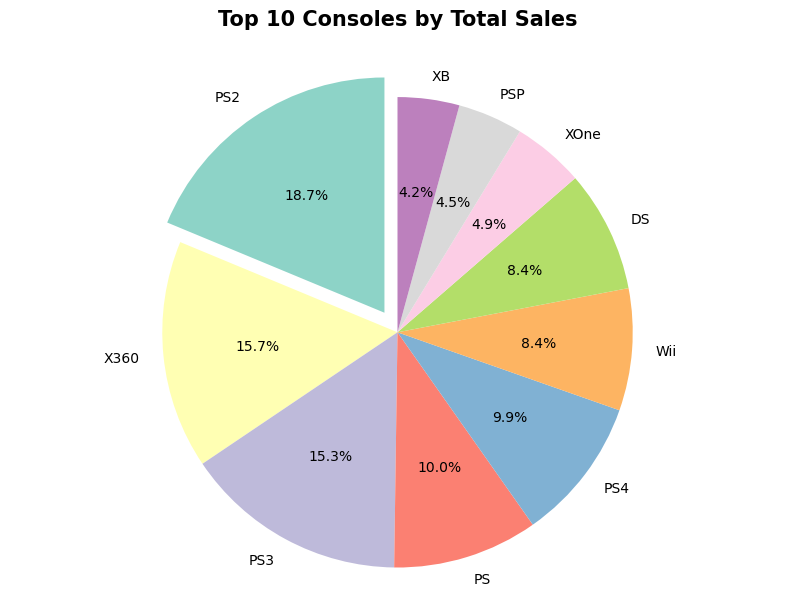

In [21]:
import matplotlib.pyplot as plt

sales_by_consoles = df.groupby('console')['total_sales'].sum().sort_values(ascending=False)
top_ten_consoles = sales_by_consoles.head(10)

plt.figure(figsize=(10, 7))

plt.pie(top_ten_consoles, 
        labels=top_ten_consoles.index, 
        autopct='%1.1f%%',      
        startangle=90,        
        colors=plt.cm.Set3.colors,
        explode=(0.1,0,0,0,0,0,0,0,0,0)) 

plt.title('Top 10 Consoles by Total Sales', fontsize=15, pad=20,fontweight='bold')
plt.axis('equal') 
plt.show()


Observations:
- Sony PlayStation has the largest market share in the gaming industry over the years. It has five consoles in the top 10 (PS2,PS3,PS,PS4,PSP). This suggests a very high rate of 'generational carry-over' where users stay within the PlayStation ecosystem when a new console launches.

- Xbox 360 vs PS3: During the 7th generation of consoles, Microsoft and Sony were equally matched, with Xbox 360 having a market share of 15.7% and PS3 having 15.3%. This reflects an era where Microsoft successfully challenged Sony's status in the gaming industry, through a strong online service (Xbox Live).

- Nintendo's consoles, NDS and Wii, are within the top 10 consoles. This reveals the success of Nintendo entering the market of casual gamers, despite lower hardware power than PlayStation and Xbox.

Insights:
- It is risky for game developers to develop platform-exclusive games. Developing for both PlayStation and Xbox ensures access to more than half of the gaming market. That's why nowadays many platform-exclusive games are released to another platform like PC a few years after the first release for console.

- The presence of NDS and PSP in the top ten consoles indicates that the handheld gaming market is too significant to be ignored. Handheld developers should now shift their focus towards the mobile market, as the casual gamer market has now transitioned from NDS and PSP to modern smartphones.

##### Multivariate Analysis

We first plot the correlation heatmap for numerical features including game scores,global and regional sales,year of release to see whether they have relationship between each other:

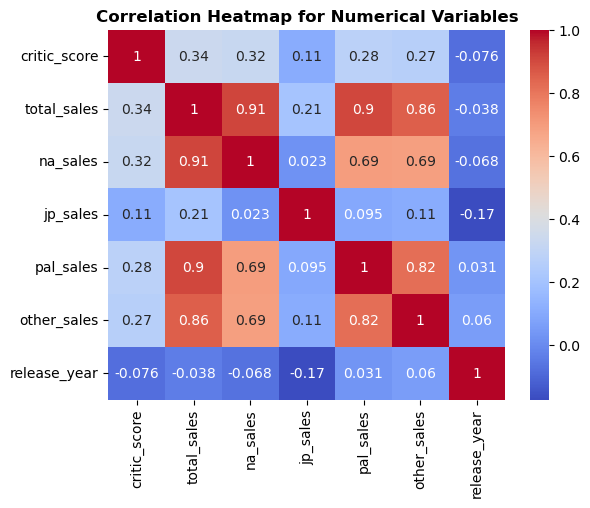

In [22]:
column_to_compare = ['critic_score','total_sales','na_sales','jp_sales','pal_sales','other_sales','release_year']
correlation_matrix = df[column_to_compare].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap for Numerical Variables',fontweight='bold')
plt.show()

Observations:
- There is a high correlation between North America sales and total sales(0.91), between European and African sales and total sales(0.9), between other regional sales and total sales(0.86), but a low correlation between Japanese sales and total sales(0.21).  


Insights:
- Since global sales has a high correlation with other countries in the world, except for Japan, it suggests that Japan is a 'unique' market. Japanese market follows its own rules and does not move in syn with other markets. Some AAA IPs which are huge hits in America and Europe (like Grand Theft Auto,Call of Duty) may only perform modestly in Japan. Conversely, a game can be a 'cultural symbol' in Japan(like Dragon Quest,Monster Hunter franchise) but remain a niche product globally. 

- For AAA IPs, publishers should launch them on cross-platform to capture the peak sales. If a game is a hit on PS5 in North America, it will probably become a hit on Xbox in Europe. Developers should invest heavily on graphics and cinematic storytelling as these are the key components to the success of a AAA game. Besides, North America sales can be used as a leading indicator. If pre-orders are high in North America, publishers should immediately increase marketing spend in Europe and Africa to acheive high global sales.

- For Japanese markets, publishers should focus on cultural adaptation, which involves changing character designs and marketing themes to fit local tastes.

To further investigate the preference of games in different regions, we use a bar chart to demonstrate regional sales data against different genres. We only choose certain genres to compare, including the top three genres (Sports,Action,Shooter) and other genres which are popular in Japan(Role-Playing,Visual Novel etc):

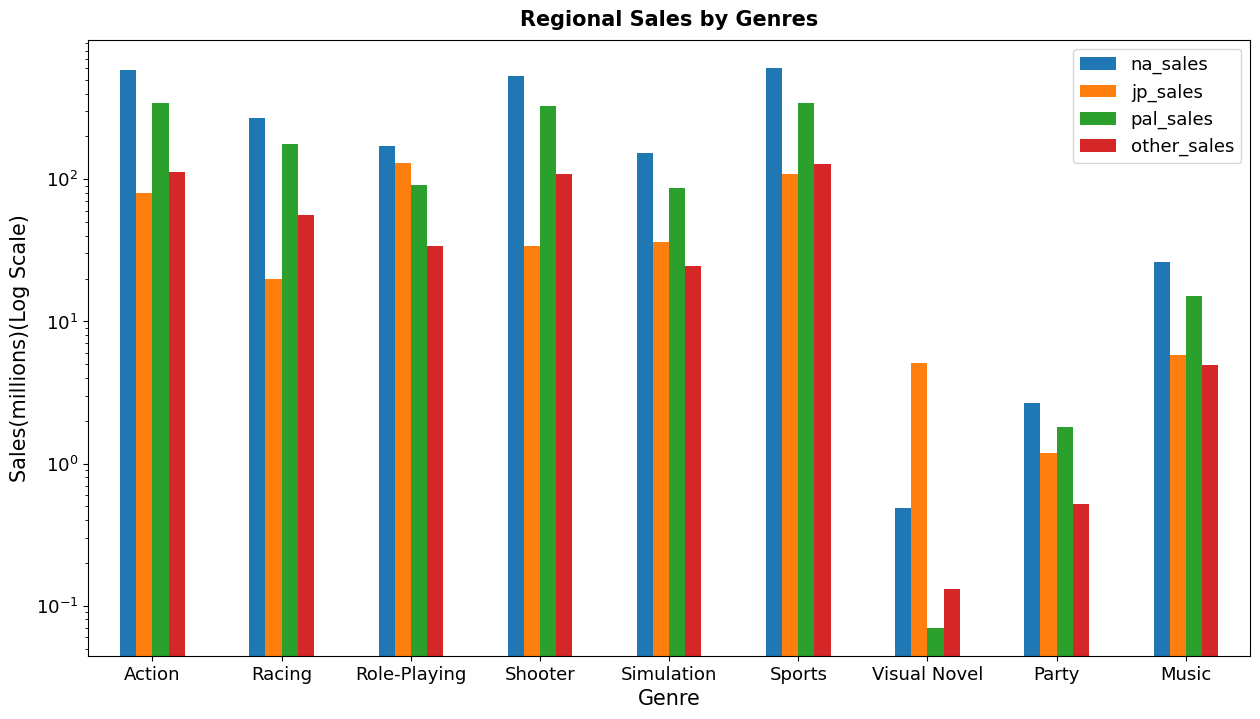

In [24]:
genre_sales = df.groupby('genre')[['na_sales', 'jp_sales','pal_sales','other_sales']].sum()

genre_sales.loc[['Action','Racing','Role-Playing','Shooter','Simulation','Sports','Visual Novel','Party','Music']].plot(kind='bar',figsize=(15,8))

plt.yscale('log')
plt.title('Regional Sales by Genres',fontsize=15,pad=10,fontweight='bold')
plt.xlabel('Genre',fontsize=15)
plt.ylabel('Sales(millions)(Log Scale)',fontsize=15)
plt.legend(fontsize=13, loc='upper right')
plt.tick_params(axis='x', labelsize=13, rotation=0)
plt.tick_params(axis='y', labelsize=13)
plt.show()

Observations:
- The genres which have high sales in North America, Europe, Africa and other parts of the world, like Action, Shooter and Sports, have the lowest sales numbers in Japan.

- Role-Playing game has high sales in Japan, with sales numbers only slightly lower than that of North America. Visual Novel is the most noticeable genre where Japanese sales is the highest compared to other regions.

Insights:
- Japan has a unique perference for RPG and Visual Novel games. AAA IPs in Japan are not as popular as in the Western countries.

- Publishers should realize the importance of localized marketing in Japan and adopt special marketing strategies for Japan. For instance, publishers should focus on digital distribution to avoid the high cost of physical shipping and retail.

- Indie developers can consider making low-budget RPG and Visual Novel games which aim for Japanese market.

### Challenges and Limitations

Challenges faced during the project:
- "One Man Army": As I do not form group with other classmates, I need to do all the work myself, including searching for dataset, coding, performing data cleansing and analysis, writing report and giving presentation. I spend in average three hours per day on this project, which I feel exhausted and overwhelmed.  

- Handling missing values and zeros in dataset: In the original dataset, there are many missing values and zeros. I tried to remove all rows which have missing values and zeros, but doing that would remain only about 1700 rows, which I think is not enough for data analysis, thus affecting the accuracy. In the end I decided to perform data cleansing column by column.   

- Handling outliers: The 'total sales' column has a wide range of values, ranging from 0.01 to 20. When plotting the graphs involving the total sales, the great difference in values often results in difficult or unpleasant visualization. So I applied logarithmic scaling to these values, which enables easy and clear visualization.

Limitations of the approach or dataset:
- Digital vs physical sales: It is unsure whether the dataset contains the digital sales data. In the modern era, digital downloads (Steam, Epic, PS Store) account for over 80% of sales. If the dataset lacks digital data, the total sales for newer consoles will be significantly underestimated.

- Survivor bias: The dataset only contains games that made it to market. It doesn't show the thousands of cancelled projects or games that sold zero copies, which limits my ability to analyze "failure factors".

Potential areas for future improvement:
- Predictive modeling for hype vs reality: The current dataset looks at historical success. A powerful next step would be to correlate pre-release data with final sales. Pre-release data includes the
number of likes from social media (Twitter, Instagram), YouTube trailer view counts, and Steam "Wishlist" numbers. The goal is to build a machine Learning model to see if "Social Sentiment" is a better predictor of success than "Critic Scores". This would help publishers decide where to allocate their marketing budget before a game launches.

- The impact of game subscription: With the rise of subscription service (Xbox Game Pass, PS Plus, EA Play), many users no longer buy individual games. Future analysis would be how being added to subscription service affects the total sales of a game. Would subscription lower the sales of a game because players can now access thousands of games through monthly fee? Can the total sales actually reflect the popularity of a game or we should count the number of downloads in subscription service instead? These are the questions to be investigated in future analysis. 

### Future Work

Ideas or approaches that were not implemented and the reasons:
- Principal Component Analysis(PCA): PCA is a technique that can reduce the number of variables for easier data analysis. It involves finding the principal components that can represent variables of similar attributes. Since the implementation of PCA is quite complicated and time-consuming, I did not include it in my analysis. 

- Random Forest: Random Forest is a method in machine learning that can predict or fill the missing values in a feature. In Random Forest model, many decision trees are built to form a 'forest'. Each decision tree contains criteria that are used to predict the result. The final result is then determined by majority voting(for categorical variables) or averaging(for numerical variables). In my analysis, I used KNN imputation to fill the missing values of the variable 'critic_score'. I only extracted the numerical features like total sales and sales in different regions to find the most similiar rows to approximate the missing scores. Random forest might be more accurate in approximating the missing scores since it can take categorical variables(console, genre, publisher etc)into account. 

- Time Series Forcast: The dataset contains the variable 'release_year'. Time Series analysis could have been used to predict the future values of certain features, such as total sales and regional sales. But I did not include it in my analysis since it is not really accurate to predict future sales using the past data.

### Conclusion

Summary of objectives and achievements:
- This project aims to analyze the video game sales over 40 years of gaming history and provide recommendations and marketing strategies for game publishers and developers. 

- In this analysis, we have looked into how the video game sales and the game scores distribute among all the games, the correlation between sales number and game score, the most popular genres over the years, the market share by different consoles, how the regional sales are related to the global sales and game preferences by different regions. 

Key insights and recommendations:
- The top-tier games account for more than 90% of global total sales, like Grand Theft Auto, Call of Duty and FIFA. Continuation of these IPs is a safe choice for large publishers. They do not need to add too many new elements to a new game in the franchise and it still manages to drive sales among die-hard fans. 

- Although game score is not an indicator for high sales, a game must achieve a high score in order to sell millions of copies, preferably above 7. 

- The game genre is a key determining factor for sales. To achieve high sales, publishers and developers should target large-market genres like action, shooter and sports. The not-so-popular genres can have good reviews but low sales due to their niche market. 

- Publishers should adopt 'cross-platform' strategy, meaning that games should be released on multiple platforms instead of 'platform-exclusive' in order to capture the majority of console markets. 

- The large market share by PSP and NDS shows the importance of handheld gaming market. Since many old gamers of PSP and NDS have now shifted to mobile games, publishers should release their games not only on traditional consoles, but also on mobile phones. 

- Japanese gamers have unique preference for RPG and Visual Novel games, unlike America and Europe where AAA games are mainstream. To successfully penetrate the Japanese market, developers should incorporate more RPG elements and adopt an anime-inspired aesthetic for character design.

- Small studios or indie developers should consider bringing their titles to Game Pass to offset low sales and boost game exposure.

### Reference

Divekar, B. (2024). Video Game Sales and Industry Data (1980-2024) [Data set]. Kaggle. https://www.kaggle.com/datasets/bhushandivekar/video-game-sales-and-industry-data-1980-2024